# GINN — Gaussian-Informed Neural Network

**Four feature sets, one question:** how much does each set of symmetry descriptors contribute to binding-energy prediction and the level of confidence?

| Label | Features | Physics |
|---|---|---|
| **LDM** | $Z,\,N,\,A^{2/3},\,T_z$ | Liquid-drop / Bethe–Weizsäcker macroscopic inputs |
| **LDM+SU(4)** | LDM + $\mathcal{C}_2,\mathcal{C}_4[\mathrm{SU}(4)]$ | Adds Wigner spin–isospin supermultiplet symmetry |
| **LDM+SU(3)** | LDM + $N_{\hbar\omega},\mathcal{C}_2,\mathcal{C}_3[\mathrm{SU}(3)]$ | Adds shell structure and deformation |
| **LDM+SU(4)+SU(3)** | LDM + $\mathcal{C}_2,\mathcal{C}_4[\mathrm{SU}(4)]$ + $N_{\hbar\omega},\mathcal{C}_2,\mathcal{C}_3[\mathrm{SU}(3)]$ | Adds shell structure, deformation and supermultiplet |

Each is trained with the negative log-likelihood (NLL) loss, i.e., 
$$\mathcal{L}_{\rm NLL} = \left\langle \frac{(y-\mu)^2}{2\sigma^2} + \log\sigma \right\rangle$$
and the loss from Garvey–Kelson relations.
At the end, the predicted mean $\mu(N,Z)$ and uncertainty $\sigma(N,Z)$ are visualised on the nuclear chart.

## 1 — Imports

In [46]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve().parent))

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import symass
from symass import Normalizer, SOAP, build_gk_indices, train, train_pinn, evaluate

torch.manual_seed(42)
np.random.seed(42)

## 2 — Data

Load nuclear masses, filtered to $Z \geq 8$, $N \geq 8$, and add $A^{2/3}$ as a derived column.

In [2]:
df = symass.load_dataframe(keep_extrapolated=False, Zmin=8, Nmin=8)
df['A_23'] = df['A'].astype(float) ** (2/3)

FEATURE_SETS = {
    'LDM'            : ['Z', 'N', 'A_23', 'T_z'],
    'LDM+SU(4)'      : ['Z', 'N', 'A_23', 'T_z', 'C2_4', 'C4_4'],
    'LDM+SU(4)+SU(3)': ['Z', 'N', 'A_23', 'T_z', 'C2_4', 'C4_4', 'Nhw', 'C2_3', 'C3_3'],
    'LDM+SU(3)'      : ['Z', 'N', 'A_23', 'T_z', 'Nhw', 'C2_3', 'C3_3'],
}

TARGET     = 'BE_total_MeV'
y_all      = df[TARGET].to_numpy(dtype=np.float32).reshape(-1, 1)
N_all      = df['N'].to_numpy(dtype=int)
Z_all      = df['Z'].to_numpy(dtype=int)
ame_source = df['ame_source'].to_numpy()

print(f'Total nuclei : {len(df)}')

  [warn] Could not load pickle (ModuleNotFoundError: No module named 'numpy._core.numeric').
         Falling back to CSV — consider re-running src/build.py to rebuild the pickle in this environment.
Total nuclei : 2457


## 3 — Train / Test / Val split

Nuclei measured in AME2016 form the train+test pool
(80/20 random split); nuclei newly measured between 2016 and 2020 form the
validation set. The validation set is never touched during training or
hyperparameter tuning---it is a genuine extrapolation benchmark.

In [3]:
idx_2016 = np.where(ame_source == 'AME2016')[0]
idx_val  = np.where(ame_source == 'AME2020')[0]

rng   = np.random.RandomState(0)
perm  = rng.permutation(len(idx_2016))
split = int(0.8 * len(idx_2016))
tr    = idx_2016[perm[:split]]
te    = idx_2016[perm[split:]]
val   = idx_val

print(f'Train : {len(tr)}  |  Test : {len(te)}  |  Val (AME2020) : {len(val)}')

Train : 1908  |  Test : 478  |  Val (AME2020) : 71


## 4 — GINNNet architecture

The network shares a backbone with the FINN but splits into two heads:

```
Input (n_features)
        ↓
   [64 → 128 → 64]   (shared backbone, ReLU)
        ↓
   ┌────┴────┐
  mu      log_σ     (one linear head each)
              ↓
           σ = exp(log_σ).clamp(1e-4, 10)
```

Using $\log\sigma$ as the raw output guarantees $\sigma > 0$ and gives the
optimiser an unconstrained parameter to work with.
Initialising the $\log\sigma$ head bias to 0 means $\sigma = 1$ at the start,
matching the MSE assumption and giving a stable warm start.

In [37]:
class GINNNet(nn.Module):
    def __init__(self, n_features, hidden=[64, 128, 64], activation=nn.ReLU):
        super().__init__()

        def make_act(width):
            # PReLU gets one learnable slope per neuron (init 0.1);
            # parameter-free activations (ReLU, GELU, SiLU, ...) ignore `width`.
            if activation is nn.PReLU:
                return nn.PReLU(num_parameters=width, init=0.1)
            return activation()

        layers, d = [], n_features
        for h in hidden:
            layers += [nn.Linear(d, h), make_act(h)]
            d = h
        self.backbone   = nn.Sequential(*layers)
        self.mu_head    = nn.Linear(d, 1)
        self.sigma_head = nn.Linear(d, 1)
        nn.init.constant_(self.sigma_head.bias, 0.0)  # sigma=1 at init

    def forward(self, x):
        h     = self.backbone(x)
        mu    = self.mu_head(h)                                   
        sigma = torch.exp(self.sigma_head(h)).clamp(1e-4, 10.0)  
        return mu, sigma


def nll_loss(out, y, beta=0.5):
    mu, sigma = out
    var = sigma**2
    nll = 0.5 * (y - mu)**2 / var + sigma.log()
    if beta > 0:
        nll = nll * var.detach()**beta
    return nll.mean()


def mdn_predict(mu, sigma):
    return mu


## 5 — Training helper

A single function `run_model` encapsulates the full pipeline for one
(feature set, loss variant) combination:
build tensors → normalise → instantiate BENet → train → evaluate.

**Optimiser:** SOAP (second-order, Shampoo-as-Adam-Preconditioner).
Consistently outperforms Adam on this dataset.

**PINN term:** Garvey–Kelson (GK) 6-body mass relations.

In [38]:
EPOCHS     = 2000
GK_LAMBDA  = 4.0
BATCH_SIZE = 64
LR         = 1e-3
ACTIVATION = nn.PReLU      # <- swap to nn.PReLU (or nn.GELU, nn.SiLU, ...) to experiment

def run_model(feat_name, use_pinn=False, seed=1):
    feats = FEATURE_SETS[feat_name]
    X_all = df[feats].to_numpy(dtype=np.float32)

    norm  = Normalizer(X_all[tr], y_all[tr])
    X_tr_ = torch.tensor(norm.transform_X(X_all[tr]))
    y_tr_ = torch.tensor(norm.transform_y(y_all[tr]))
    X_te_ = torch.tensor(norm.transform_X(X_all[te]))
    y_te_ = torch.tensor(norm.transform_y(y_all[te]))
    X_v_  = torch.tensor(norm.transform_X(X_all[val]))
    y_v_  = torch.tensor(norm.transform_y(y_all[val]))

    loader = DataLoader(TensorDataset(X_tr_, y_tr_),
                        batch_size=BATCH_SIZE, shuffle=True)

    torch.manual_seed(seed)
    model   = GINNNet(n_features=len(feats), activation=ACTIVATION)
    opt     = SOAP(model.parameters(), lr=LR, betas=(0.95, 0.95),
                   weight_decay=0.0, precondition_frequency=10)
    eval_fn = lambda m, X: mdn_predict(*m(X)).detach().numpy()

    label = f'{feat_name} / {"PINN" if use_pinn else "NLL "}'
    if use_pinn:
        gk = build_gk_indices(N_all[tr], Z_all[tr])
        train_pinn(model, loader, opt, nll_loss, X_tr_, gk,
                   pred_fn=mdn_predict,
                   gk_lambda=GK_LAMBDA, epochs=EPOCHS,
                   print_every=200, label=label, grad_clip=1.0)
    else:
        train(model, loader, opt, nll_loss,
              epochs=EPOCHS, print_every=200, label=label, grad_clip=1.0)

    metrics = {
        'train': evaluate(model, X_tr_, y_tr_, norm=norm, pred_fn=eval_fn),
        'test' : evaluate(model, X_te_, y_te_, norm=norm, pred_fn=eval_fn),
        'val'  : evaluate(model, X_v_,  y_v_,  norm=norm, pred_fn=eval_fn),
    }
    return model, norm, metrics, (X_tr_, X_te_, X_v_, y_tr_, y_te_, y_v_)

## 6 — Train all models

In [39]:
results = {}  # key: (feat_name, 'NLL'|'PINN')

for feat_name in FEATURE_SETS:
    for use_pinn, tag in [(True, 'PINN')]:
    # for use_pinn, tag in [(True, 'PINN'), (False, 'MSE')]: # USE THIS LINE IF YOU ALSO WANT TO COMPARE WITH PURE NLL LOSS
        sep = '=' * 60
        print(f'\n{sep}')
        model, norm, metrics, tensors = run_model(feat_name, use_pinn=use_pinn)
        results[(feat_name, tag)] = (model, norm, metrics, tensors)

print('\nAll models trained.')


  [LDM / PINN]  epoch    200  loss -0.014871
  [LDM / PINN]  epoch    400  loss -0.015260
  [LDM / PINN]  epoch    600  loss -0.015394
  [LDM / PINN]  epoch    800  loss -0.011604
  [LDM / PINN]  epoch   1000  loss -0.012144
  [LDM / PINN]  epoch   1200  loss -0.011247
  [LDM / PINN]  epoch   1400  loss -0.015154
  [LDM / PINN]  epoch   1600  loss -0.011893
  [LDM / PINN]  epoch   1800  loss -0.013103
  [LDM / PINN]  epoch   2000  loss -0.012176

  [LDM+SU(4) / PINN]  epoch    200  loss -0.011727
  [LDM+SU(4) / PINN]  epoch    400  loss -0.008656
  [LDM+SU(4) / PINN]  epoch    600  loss -0.010704
  [LDM+SU(4) / PINN]  epoch    800  loss -0.010712
  [LDM+SU(4) / PINN]  epoch   1000  loss -0.007857
  [LDM+SU(4) / PINN]  epoch   1200  loss -0.007890
  [LDM+SU(4) / PINN]  epoch   1400  loss -0.005895
  [LDM+SU(4) / PINN]  epoch   1600  loss -0.006617
  [LDM+SU(4) / PINN]  epoch   1800  loss -0.007907
  [LDM+SU(4) / PINN]  epoch   2000  loss -0.008726

  [LDM+SU(4)+SU(3) / PINN]  epoch    

## 7 — Results

RMSE and MAE in MeV.  Val RMSE is the extrapolation benchmark.

In [40]:
header = (
    f"{'Model':<26} {'Train RMSE':>11} {'Test RMSE':>10} {'Val RMSE':>10}"
    f" {'Train MAE':>11} {'Val MAE':>9}"
)
print(header)
print('\u2500' * len(header))

for feat_name in FEATURE_SETS:
    for tag in ['PINN']: # 'NLL', 
        _, _, m, _ = results[(feat_name, tag)]
        label = f'{feat_name}-{tag}'
        print(
            f'{label:<26}'
            f"{m['train']['rmse']:>11.3f}"
            f"{m['test']['rmse']:>10.3f}"
            f"{m['val']['rmse']:>10.3f}"
            f"{m['train']['mae']:>11.3f}"
            f"{m['val']['mae']:>9.3f}"
        )

Model                       Train RMSE  Test RMSE   Val RMSE   Train MAE   Val MAE
──────────────────────────────────────────────────────────────────────────────────
LDM-PINN                        0.869     1.149     1.304      0.672    1.053
LDM+SU(4)-PINN                  0.604     0.654     1.046      0.460    0.880
LDM+SU(4)+SU(3)-PINN            0.400     0.488     0.793      0.291    0.593
LDM+SU(3)-PINN                  1.036     1.404     1.280      0.770    0.954


## 8 — Prediction diagnostics

True-vs-predicted scatter and residual heatmap on the nuclear chart for each feature set.


--- LDM / PINN ---


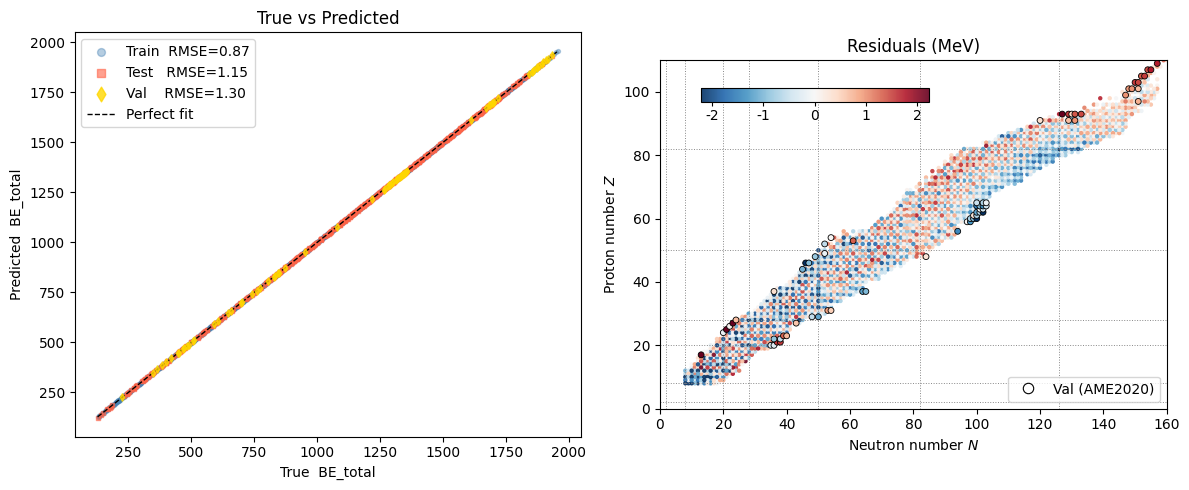


--- LDM+SU(4) / PINN ---


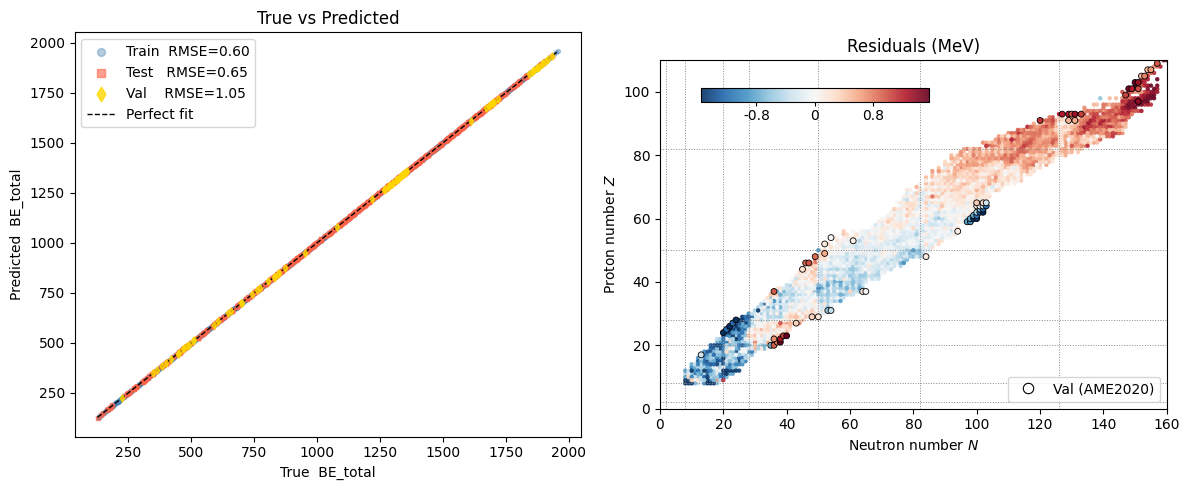


--- LDM+SU(4)+SU(3) / PINN ---


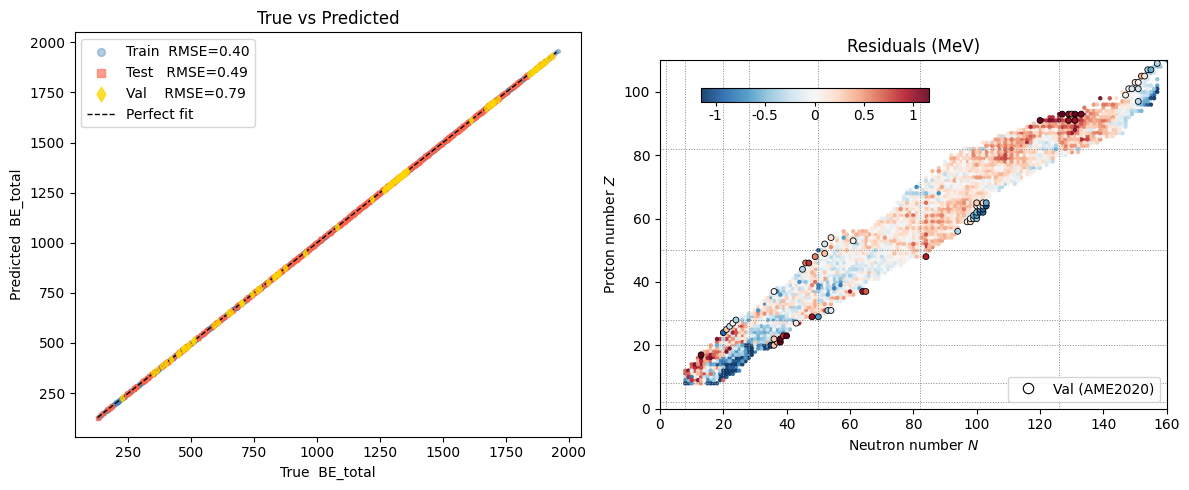


--- LDM+SU(3) / PINN ---


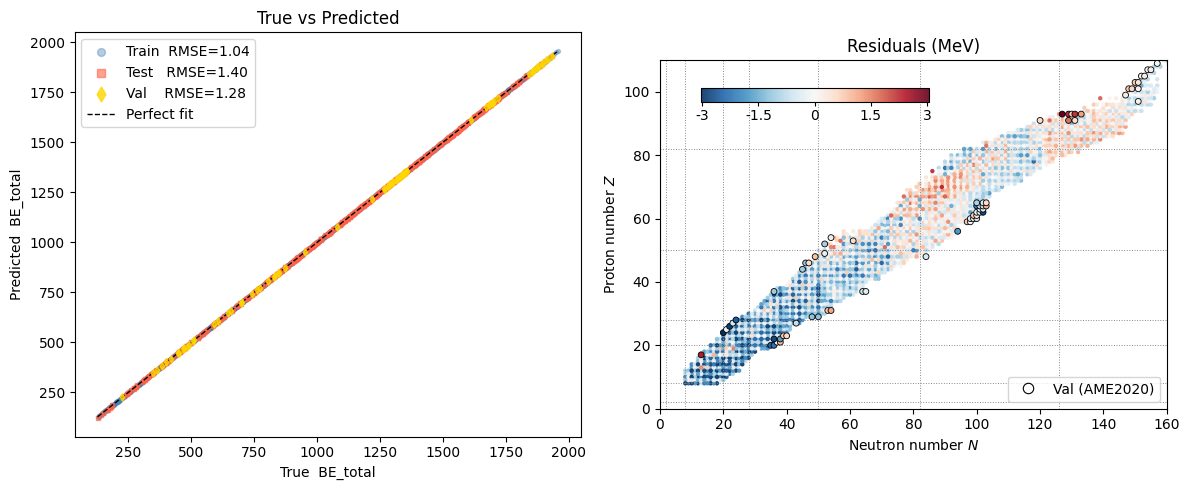

In [42]:
for feat_name in FEATURE_SETS:
    model, norm, metrics, tensors = results[(feat_name, 'PINN')]
    print(f'\n--- {feat_name} / PINN ---')
    symass.plot_predictions(
        metrics['train'], metrics['test'],
        tr_N=N_all[tr], tr_Z=Z_all[tr],
        te_N=N_all[te], te_Z=Z_all[te],
        val_metrics=metrics['val'],
        val_N=N_all[val], val_Z=Z_all[val],
    )

## 9 — $\mu$ and $\sigma$ on the nuclear chart

The predicted mean $\mu(N,Z)$ should closely match the experimental binding
energy.  The uncertainty $\sigma(N,Z)$ reveals where the model is uncertain.

Inference is run on the entire dataset (train + test + val) so the map
covers the full nuclear chart.

In [43]:
def predict_chart(model, norm, feats):
    X = df[feats].to_numpy(dtype=np.float32)
    X_norm = torch.tensor(norm.transform_X(X))
    model.eval()
    with torch.no_grad():
        mu_n, sigma_n = model(X_norm)
    # Inverse-transform: mu back to MeV; sigma scales by y_std only (no shift)
    mu_phys    = mu_n.numpy().ravel() * norm.y_std + norm.y_mean
    sigma_phys = sigma_n.numpy().ravel() * norm.y_std
    return mu_phys, sigma_phys

### $\sigma$ comparison across feature sets — shared color scale

Plotting all $\sigma$ maps side-by-side with a single shared color
scale makes it easy to see how uncertainty decreases as more physics is
added. The scale is set from the 2nd to 98th percentile of all $\sigma$
values across all models to avoid a single outlier compressing the palette.

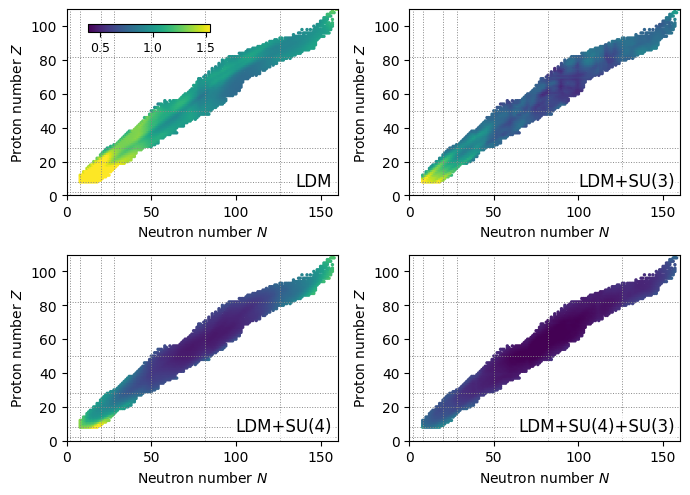

In [44]:
# Collect sigma for every PINN model
# pinn_names = [k for k in FEATURE_SETS]
pinn_names = [
    'LDM',          'LDM+SU(3)',
    'LDM+SU(4)',    'LDM+SU(4)+SU(3)',
]

sigma_maps = {}
for feat_name in pinn_names:
    model, norm, _, _ = results[(feat_name, 'PINN')]
    _, sigma_phys = predict_chart(model, norm, FEATURE_SETS[feat_name])
    sigma_maps[feat_name] = sigma_phys

# Shared colour scale clipped at 2nd/98th percentile
import matplotlib.colors as mcolors
all_sigma = np.concatenate(list(sigma_maps.values()))
vmin = float(np.percentile(all_sigma, 2))
vmax = float(np.percentile(all_sigma, 98))
shared_norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

n  = len(pinn_names)
fig, axes = plt.subplots(2, 2, figsize=(7, 5.1), squeeze=False)
axes = axes.flatten()

sc = None
for ax, feat_name in zip(axes, pinn_names):
    sc = ax.scatter(
        N_all, Z_all,
        c=sigma_maps[feat_name],
        cmap='viridis', norm=shared_norm,
        s=6, linewidths=0,
    )
    for m in symass.SHELLS_MAGIC:
        ax.axvline(m, color='#888888', lw=0.7, ls=':')
        ax.axhline(m, color='#888888', lw=0.7, ls=':')
    ax.set_xlim(0, int(N_all.max()))
    ax.set_ylim(0, int(Z_all.max()))
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('Neutron number $N$')
    ax.set_ylabel('Proton number $Z$')
    # ax.set_title(feat_name, fontsize=10)
    ax.text(0.98, 0.03, feat_name,
                    transform=ax.transAxes, ha="right", va="bottom",
                    fontsize=12,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.75, ec="none"))

# Single shared colorbar on the right
cax  = axes[0].inset_axes([0.08, 0.88, 0.45, 0.04])
cbar = fig.colorbar(sc, cax=cax, shrink=0.2, pad=0.02, orientation="horizontal")
cbar.ax.tick_params(labelsize=9)
#fig.suptitle(r'Predicted uncertainty $\sigma(N,Z)$ — PINN models (shared scale)', fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig("figures/sigmas_GINN", dpi=500, bbox_inches="tight")
plt.show()

## 10 — SHAP feature importance

SHAP values are computed on the mean head ($\mu$), so they measure
the contribution of each feature to the binding-energy prediction, directly
comparable to the FINN SHAP results.


--- SHAP: LDM ---


/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:593: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


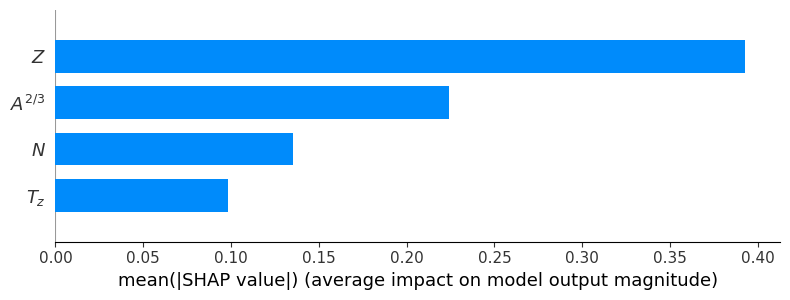

/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:605: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


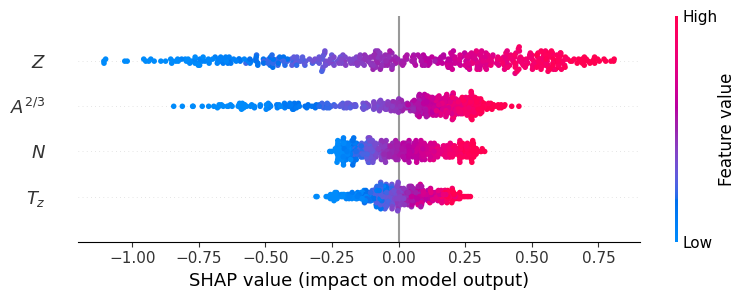


--- SHAP: LDM+SU(4) ---


/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:593: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


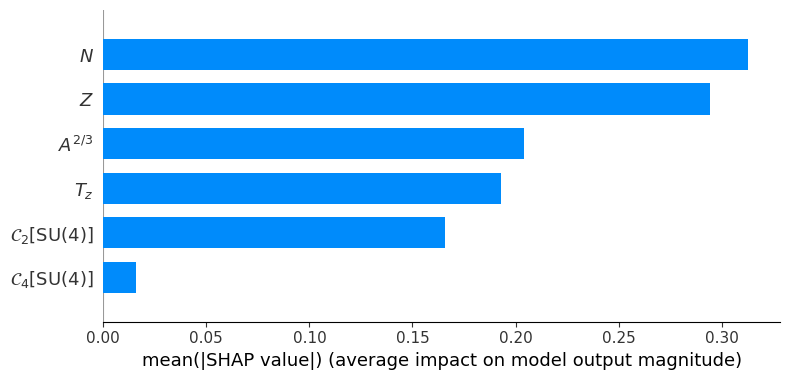

/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:605: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


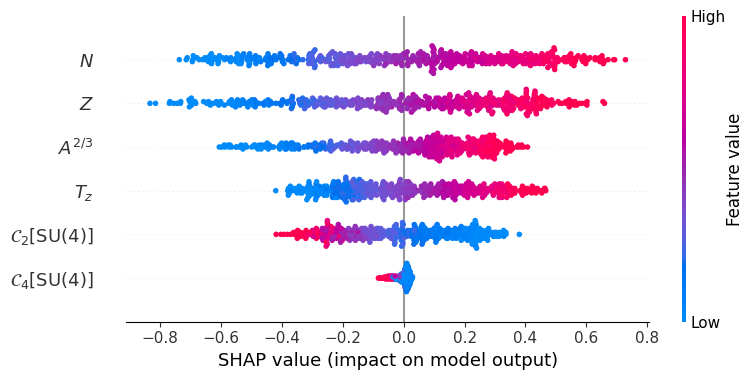


--- SHAP: LDM+SU(4)+SU(3) ---


/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:593: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


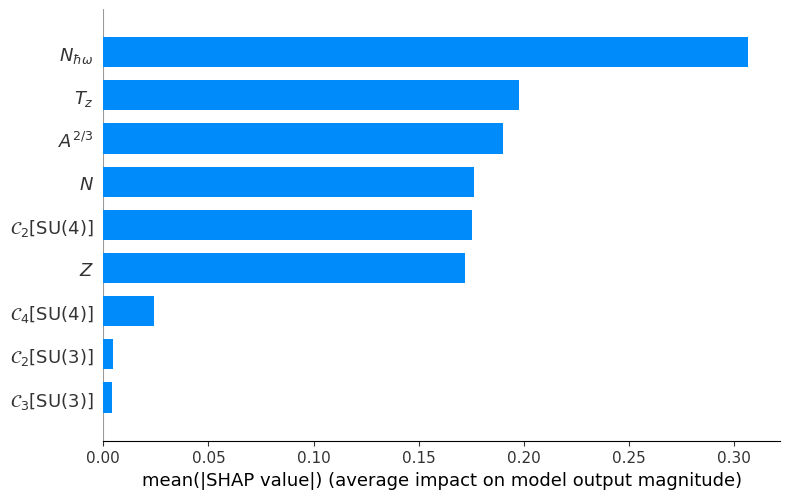

/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:605: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


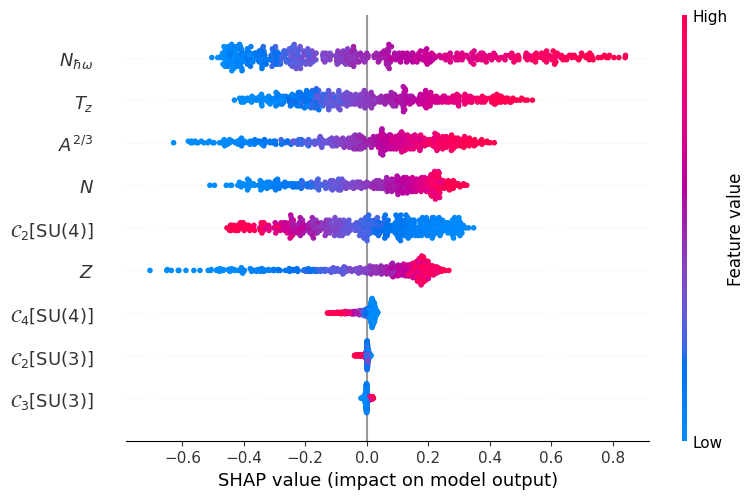


--- SHAP: LDM+SU(3) ---


/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:593: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


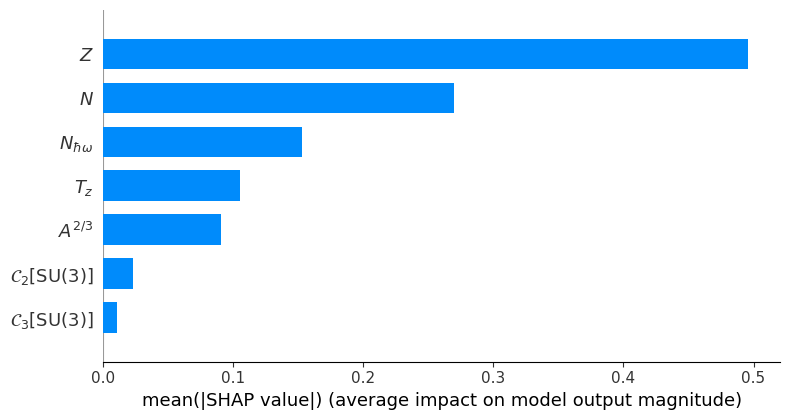

/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:605: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


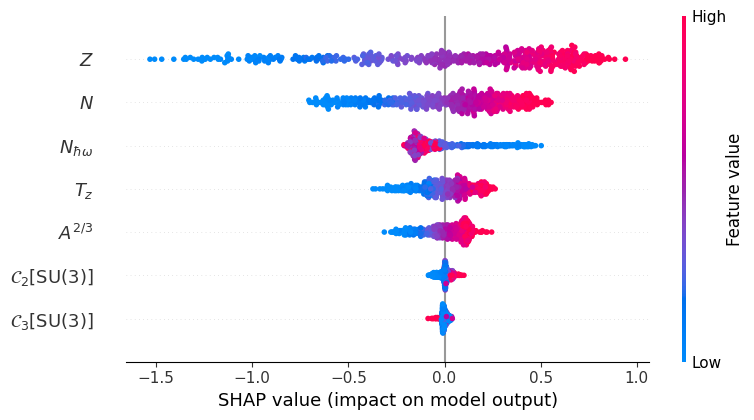

In [45]:
for feat_name in FEATURE_SETS:
    model, norm, _, tensors = results[(feat_name, 'PINN')]
    X_tr_, X_te_ = tensors[0], tensors[1]
    feats = FEATURE_SETS[feat_name]
    print(f'\n--- SHAP: {feat_name} ---')
    symass.plot_shap(model, X_tr_, X_te_, feats,
                     pred_fn=lambda out: out[0], savefig="figures/SHAP_GINN_"+feat_name)